In [2]:

import sys
import os
import time
import numpy as np

import MDAnalysis as mda
# from MDAnalysis.analysis import align
# from MDAnalysis.analysis import distances

import westpa
from westpa.analysis import Run

import matplotlib.pyplot as plt

In [3]:
#this barely needs to be a method but having the .h5 stuff compartmentalized is nice
def load_h5_pcs(h5path, miniter, maxiter):
    
    run = Run.open(h5path)

    #set maximum iteration automatically
    if maxiter == -1:
        maxiter = run.num_iterations

    pcs = [iteration.pcoords for iteration in run if (iteration.number >= miniter and iteration.number < maxiter)]

    return pcs

In [4]:
#specify input file

cftr_west = "/home/jonathan/Documents/grabelab/cftr/chloe-data"
cftr_refpc = "/home/jonathan/Documents/grabelab/cftr/refeaturization"

h5paths_names = [[f"{cftr_west}/wstp_cftr_1_degrabo/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_1", "pyrazole-1", "blue"],
                  [f"{cftr_west}/wstp_cftr_2_wynton/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_2", "pyrazole-2", "cyan"],
                  [f"{cftr_west}/wstp_lip_glpg_1/west-040925.h5", f"{cftr_refpc}/lip_glpg_1", "undecanol-1", "red"],
                  [f"{cftr_west}/wstp_lip_glpg_2/west-040925.h5", f"{cftr_refpc}/lip_glpg_2", "undecanol-2", "orange"]]

#westpa rounds to load
minround = 0
maxround = -1

run_ind = 0

data_paths = ["/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1"]
data_path = data_paths[run_ind]

In [5]:
pcs_all = load_h5_pcs(h5paths_names[run_ind][0], minround, maxround)

In [ ]:
nbins = 51
binbounds = np.arange(0,nbins,1)
bincenters = [(binbounds[i]+binbounds[i+1])/2 for i in range(len(binbounds)-1)]
boxdims_by_bin = [[] for a in range(nbins)]
membrane_thickness_by_bin = [[] for a in range(nbins)]

#later init_round values avoid questions about confounding time correlations but increase statistical noise
init_round = 1000
#loop over WE rounds
for r in range(init_round+1,2000,10):
    
    #get progress coordinates of the walkers, accounting for the occasional corrupted file
    pcs_flat = pcs_all[r-1][:,-1].flatten()
    walkers = np.load(f"{data_path}/pc_data_round_{r}_walker_numbers_v1.npy")
    pcs = [pcs_flat[w] for w in walkers]

    #assign frames to bins by pc
    bins = np.digitize(pcs, binbounds)

    #load water coordinates
    boxdims = np.load(f"{data_path}/pc_data_round_{r}_boxdims_v1.npy")
    membrane_thickness = np.load(f"{data_path}/pc_data_round_{r}_membrane_thickness_v1.npy")

    #get coordinates of waters in each bin
    for b, box, mem in zip(bins, boxdims, membrane_thickness):
        boxdims_by_bin[b].append(box)
        membrane_thickness_by_bin[b].append(mem)

for i, w in enumerate(boxdims_by_bin):
    print(f"{i}: {len(w)}")

mean_boxdims_by_bin = np.stack([np.mean(np.stack(w), axis=0) if len(w) > 0 else -np.ones(6) for w in boxdims_by_bin])
std_boxdims_by_bin = np.stack([np.std(np.stack(w), axis=0) if len(w) > 0 else np.zeros(6) for w in boxdims_by_bin])

mean_membrane_thickness_by_bin = [np.mean(w) if len(w) > 0 else -1 for w in membrane_thickness_by_bin]
std_membrane_thickness_by_bin = [np.std(w) if len(w) > 0 else 0 for w in membrane_thickness_by_bin]

0: 0
1: 1414
2: 1559
3: 1464
4: 1419
5: 1440
6: 512
7: 404
8: 377
9: 392
10: 348
11: 422
12: 350
13: 234
14: 130
15: 123
16: 288
17: 427
18: 319
19: 367
20: 317
21: 235
22: 159
23: 204
24: 224
25: 281
26: 348
27: 245
28: 111
29: 129
30: 100
31: 47
32: 43
33: 37
34: 31
35: 37
36: 44
37: 33
38: 41
39: 35
40: 36
41: 15
42: 9
43: 7
44: 0
45: 1
46: 0
47: 0
48: 0
49: 0
50: 0


(38.0, 41.0)

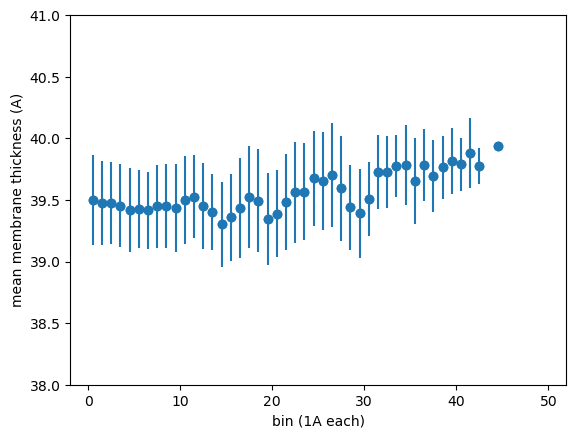

In [71]:
plt.scatter(bincenters, mean_membrane_thickness_by_bin[1:])
plt.errorbar(bincenters, mean_membrane_thickness_by_bin[1:], yerr=std_membrane_thickness_by_bin[1:], fmt = "o")

plt.xlabel("bin (1A each)")
plt.ylabel("mean membrane thickness (A)")
plt.ylim(38,41)

(101.0, 104.0)

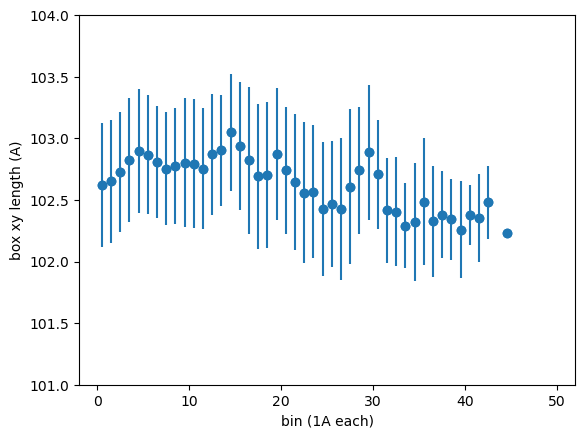

In [72]:
plt.scatter(bincenters, mean_boxdims_by_bin[1:,0])
plt.errorbar(bincenters, mean_boxdims_by_bin[1:,0], yerr=std_boxdims_by_bin[1:,0], fmt = "o")

plt.xlabel("bin (1A each)")
plt.ylabel("box xy length (A)")
plt.ylim(101,104)

Text(0, 0.5, 'box xy length (A)')

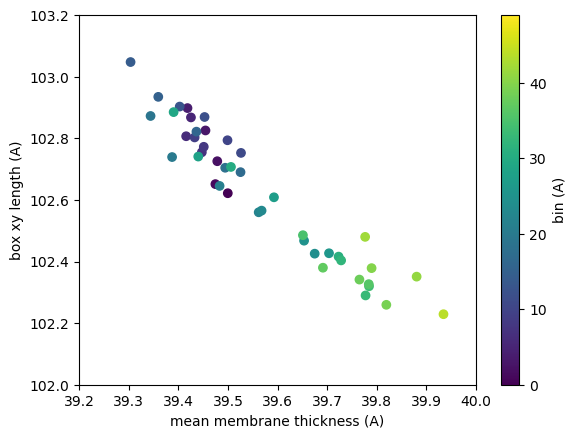

In [74]:
order_values = np.arange(len(mean_membrane_thickness_by_bin[1:]))

plt.scatter(mean_membrane_thickness_by_bin[1:], mean_boxdims_by_bin[1:,0], c = order_values)
plt.colorbar(label = "bin (A)")
plt.xlim(39.2,40)
plt.ylim(102,103.2)

plt.xlabel("mean membrane thickness (A)")
plt.ylabel("box xy length (A)")
